# Spike Hunter algorithm

Automated Candlestick Spike Pattern Labeling for Cryptocurrency Assets

In [5]:
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Fetching VELODROME/USDC data...
Fetching ADR data...
ADR data fetched successfully
Building features...
Dataset shape: (485, 38)
Date range: 2025-08-03 19:15:00 to 2025-08-08 20:15:00

=== DATA ANALYSIS ===
Price change statistics:
count    485.000000
mean       0.000277
std        0.004834
min       -0.045455
25%       -0.002024
50%        0.000000
75%        0.002049
max        0.034615
Name: price_change, dtype: float64

Volume ratio statistics:
count    485.000000
mean       1.094596
std        1.530233
min        0.000000
25%        0.000000
50%        0.393355
75%        1.666945
max        8.000000
Name: volume_ratio, dtype: float64

Candles with >1% price increase: 13
Candles with >2% price increase: 3

Label distribution: {0: np.int64(476), 1: np.int64(9)}
Spike detection rate: 0.0186

First 10 detected spikes:
              timestamp    open   close  price_change  volume_ratio  \
103 2025-08-04 21:00:00  0.0494  0.0495      0.010204      0.829804   
179 2025-08-05 16:00:00  0

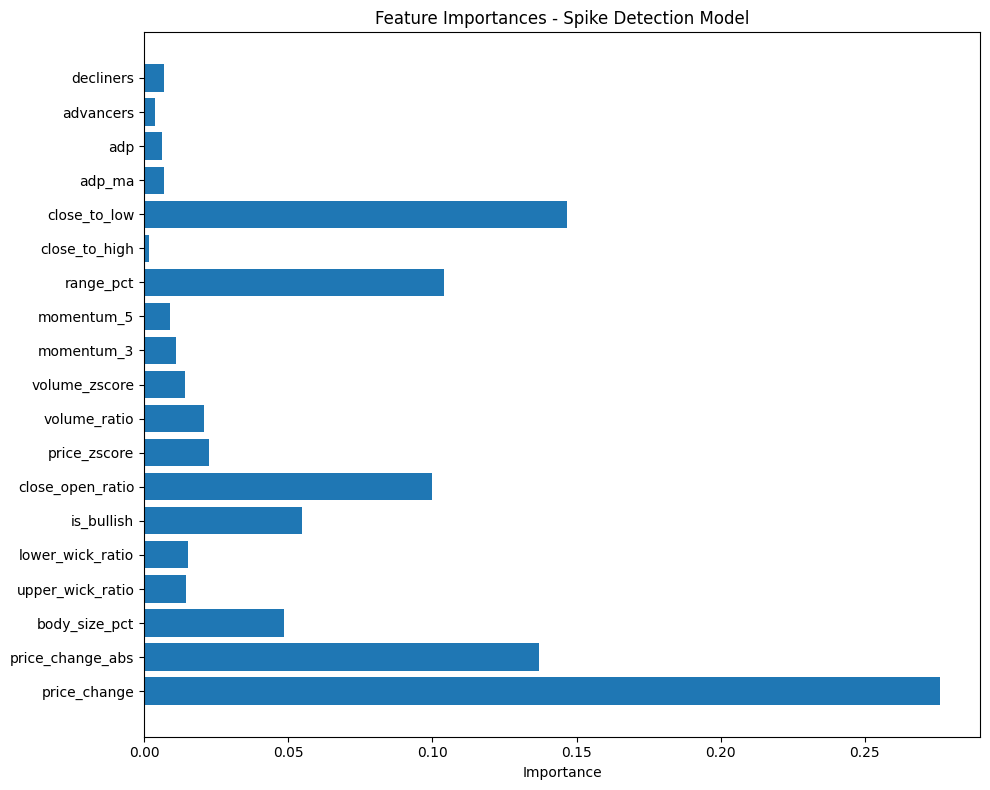


=== PLOTTING RESULTS ===
Plotting 9 detected spikes


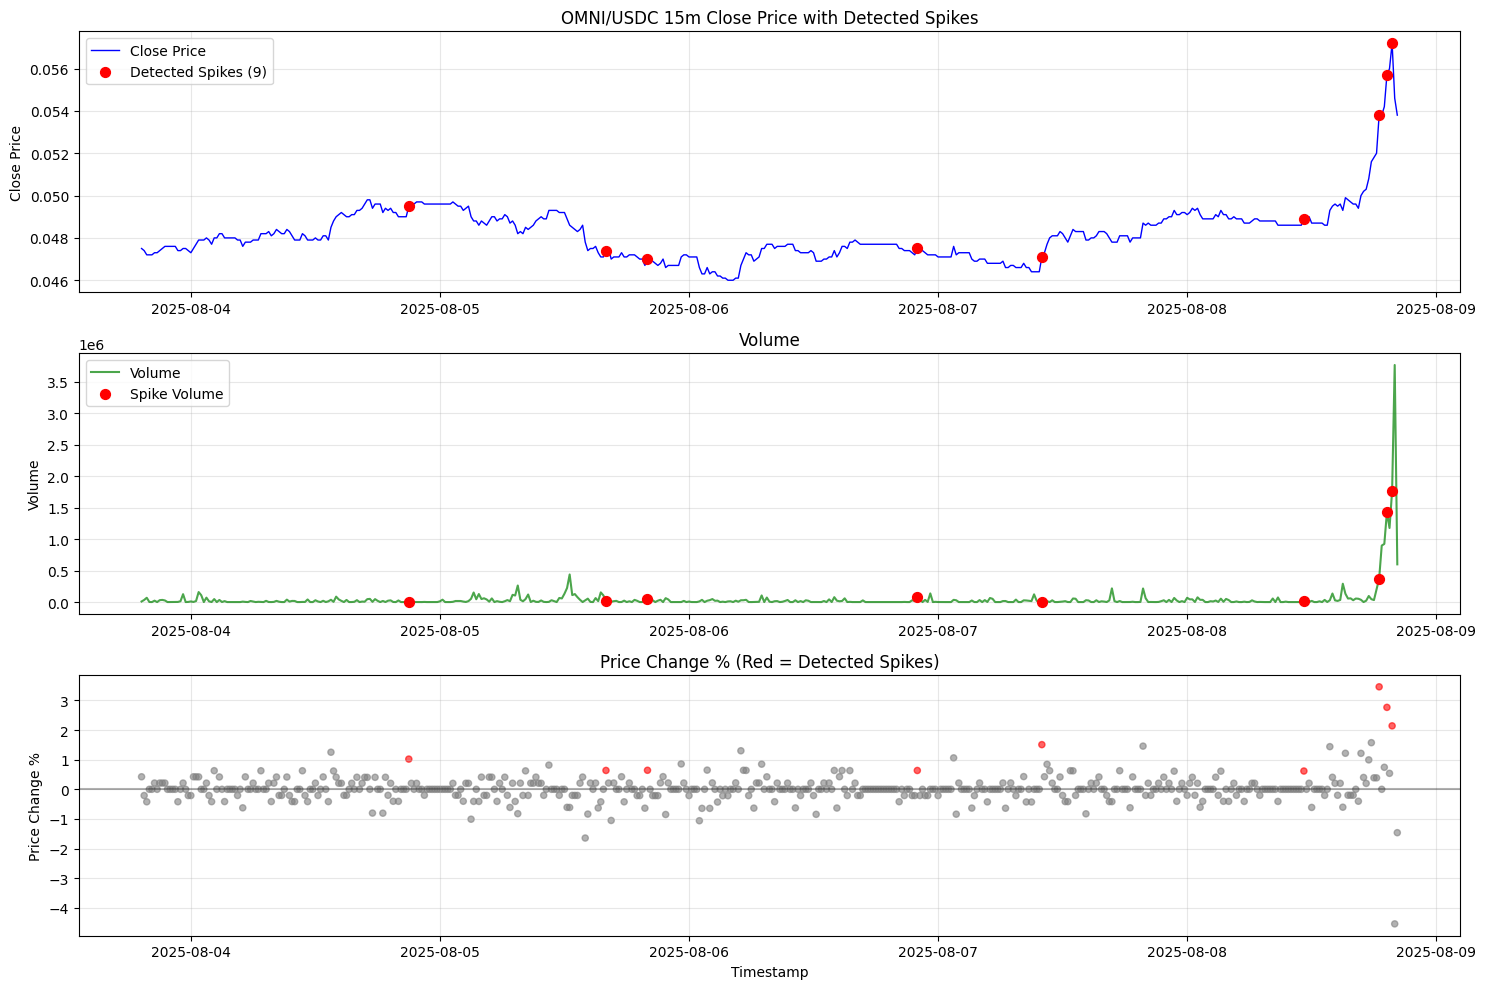


=== SPIKE DETAILS ===
              timestamp   close  price_change_pct  volume_ratio
103 2025-08-04 21:00:00  0.0495              1.02        0.8298
179 2025-08-05 16:00:00  0.0474              0.64        0.3337
195 2025-08-05 20:00:00  0.0470              0.64        2.4650
299 2025-08-06 22:00:00  0.0475              0.64        4.9140
347 2025-08-07 10:00:00  0.0471              1.51        0.2808
448 2025-08-08 11:15:00  0.0489              0.62        5.5115
477 2025-08-08 18:30:00  0.0538              3.46        3.7024
480 2025-08-08 19:15:00  0.0557              2.77        2.8639
482 2025-08-08 19:45:00  0.0572              2.14        2.0778


In [2]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib


# --- Step 1: Fetch 15m candles from Binance ---
def fetch_binance_klines(symbol="IDEXUSDC", interval="15m", limit=500, end_time=None):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    resp = requests.get(url, params=params)
    data = resp.json()
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "qav",
            "num_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    df = df[["open_time", "open", "high", "low", "close", "volume"]].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df


# --- Step 2: Fetch ADR data ---
def fetch_adr_series(size=500):
    url = f"https://api.terminal.binbot.in/charts/adr-series?size={size}"
    resp = requests.get(url)
    j = resp.json()
    df_adr = pd.DataFrame(
        {
            "timestamp": pd.to_datetime(j["data"]["timestamp"]),
            "adp_ma": j["data"]["adp_ma"],
            "advancers": j["data"]["advancers"],
            "decliners": j["data"]["decliners"],
            "adp": j["data"]["adp"],
            "total_volume": j["data"]["total_volume"],
        }
    )
    return df_adr


# --- Step 3: Spike labeling with multiple detection methods ---
def label_spike_patterns(
    df,
    price_thresh=0.015,
    vol_ratio_thresh=1.5,
    window=12,
    momentum_thresh=0.01,
    rsi_oversold=30,
    use_adr_filter=False,
    adp_col="adp",
    adp_thresh=0.5,
):
    """
    Spike detection with multiple methods:
    1. Price + Volume spike detection
    2. Momentum-based detection
    3. RSI oversold reversal detection
    4. Optional ADR filtering
    """
    labels = []

    # Calculate RSI
    df = calculate_rsi(df, window=14)

    for i in range(len(df)):
        if i < window:
            labels.append(0)
            continue

        label = 0

        # Method 1: Traditional price + volume spike
        prev_close = df.loc[i - 1, "close"]
        curr_close = df.loc[i, "close"]
        price_change = (curr_close - prev_close) / prev_close

        # Use smaller rolling window for volume comparison with microcaps
        vol_window = min(window, i)
        avg_vol = df.loc[max(0, i - vol_window) : i - 1, "volume"].mean()
        vol_ratio = df.loc[i, "volume"] / (avg_vol + 1e-6)

        if price_change > price_thresh and vol_ratio > vol_ratio_thresh:
            label = 1

        # Method 2: Momentum-based detection (consecutive positive moves)
        if not label and i >= 3:  # Reduced from window requirement
            recent_changes = df.loc[max(0, i - 3) : i, "price_change"]
            if (
                len(recent_changes) >= 3
                and (recent_changes > momentum_thresh).sum() >= 2
            ):
                total_momentum = recent_changes.sum()
                if total_momentum > price_thresh:
                    label = 1

        # Method 3: RSI oversold reversal
        if not label and i >= 14:  # RSI requires 14 periods minimum
            prev_rsi = df.loc[i - 1, "rsi"]
            curr_rsi = df.loc[i, "rsi"]
            if (
                prev_rsi < rsi_oversold
                and curr_rsi > prev_rsi + 5
                and price_change > 0.005
            ):
                label = 1

        # Optional ADR filter (only apply if use_adr_filter is True)
        if label and use_adr_filter:
            adp_val = df.loc[i, adp_col] if adp_col in df.columns else 0.5
            if pd.isna(adp_val) or adp_val >= adp_thresh:
                label = 0

        labels.append(label)

    df = df.copy()
    df["label"] = labels
    return df


def calculate_rsi(df, window=14):
    """Calculate RSI indicator"""
    df = df.copy()
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df["rsi"] = 100 - (100 / (1 + rs))
    return df


# --- Step 4: Enhanced feature engineering ---
def add_enhanced_features(df_price, df_adr=None, window=12):
    df = df_price.copy()
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Adapt window size for small datasets
    effective_window = min(window, len(df) // 8)  # More conservative for microcaps
    if effective_window < 3:
        effective_window = 3  # Absolute minimum

    # Merge ADR data if available
    if df_adr is not None:
        df_adr = df_adr.sort_values("timestamp").reset_index(drop=True)
        df = pd.merge_asof(df, df_adr, on="timestamp", direction="backward")
        df[["adp", "adp_ma", "advancers", "decliners", "total_volume"]] = df[
            ["adp", "adp_ma", "advancers", "decliners", "total_volume"]
        ].fillna(method="bfill")

    # Basic price features
    df["price_change"] = df["close"].pct_change()
    df["price_change_abs"] = df["price_change"].abs()

    # Candle features
    df["body_size"] = abs(df["close"] - df["open"])
    df["body_size_pct"] = df["body_size"] / df["open"]
    df["upper_wick"] = df["high"] - df[["close", "open"]].max(axis=1)
    df["lower_wick"] = df[["close", "open"]].min(axis=1) - df["low"]
    df["upper_wick_ratio"] = df["upper_wick"] / (df["body_size"] + 1e-6)
    df["lower_wick_ratio"] = df["lower_wick"] / (df["body_size"] + 1e-6)
    df["total_range"] = df["high"] - df["low"]
    df["range_pct"] = df["total_range"] / df["open"]

    # Trend and momentum features
    df["is_bullish"] = (df["close"] > df["open"]).astype(int)
    df["close_open_ratio"] = (df["close"] - df["open"]) / (df["open"] + 1e-6)

    # Rolling features - use effective window
    df["price_ma"] = df["close"].rolling(window=effective_window).mean()
    df["price_std"] = df["close"].rolling(window=effective_window).std()
    df["price_zscore"] = (df["close"] - df["price_ma"]) / (df["price_std"] + 1e-6)

    # Volume features
    df["volume_ma"] = df["volume"].rolling(window=effective_window).mean()
    df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-6)
    df["volume_zscore"] = (df["volume"] - df["volume_ma"]) / (
        df["volume"].rolling(window=effective_window).std() + 1e-6
    )

    # Add new volume percentile feature
    df["volume_percentile"] = (
        df["volume"].rolling(window=effective_window * 2).rank(pct=True)
    )

    # Momentum indicators
    df["momentum_3"] = df["close"].pct_change(3)
    df["momentum_5"] = df["close"].pct_change(5)

    # High/Low features
    df["high_low_ratio"] = df["high"] / df["low"]
    df["close_to_high"] = (df["high"] - df["close"]) / (df["high"] + 1e-6)
    df["close_to_low"] = (df["close"] - df["low"]) / (df["close"] + 1e-6)

    df = df.dropna().reset_index(drop=True)

    # Apply more conservative spike labeling with higher thresholds
    df = label_spike_patterns(
        df,
        price_thresh=0.020,
        vol_ratio_thresh=2.0,
        window=effective_window,
        momentum_thresh=0.015,
        use_adr_filter=False,
    )

    return df


# --- Data fetching and analysis ---
print("Fetching VELODROME/USDC data...")
df_price = fetch_binance_klines(
    "VELODROMEUSDC", interval="15m", limit=500
)  # Keep original limit for microcaps

print("Fetching ADR data...")
try:
    df_adr = fetch_adr_series(size=500)
    print("ADR data fetched successfully")
except Exception as e:
    print(f"Failed to fetch ADR data: {e}")
    df_adr = None

print("Building features...")
df = add_enhanced_features(df_price, df_adr, window=8)  # Reduced window for microcaps

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# Analyze the data before training
print("\n=== DATA ANALYSIS ===")
print(f"Price change statistics:")
print(df["price_change"].describe())
print(f"\nVolume ratio statistics:")
print(df["volume_ratio"].describe())

# Check for actual spikes in the data
upward_moves = df[df["price_change"] > 0.01]  # 1%+ moves
print(f"\nCandles with >1% price increase: {len(upward_moves)}")
large_moves = df[df["price_change"] > 0.02]  # 2%+ moves
print(f"Candles with >2% price increase: {len(large_moves)}")

# Show label distribution
label_counts = np.bincount(df["label"].astype(int))
print(f"\nLabel distribution: {dict(enumerate(label_counts))}")
print(
    f"Spike detection rate: {label_counts[1] / (label_counts[0] + label_counts[1]):.4f}"
)

# Show some examples of detected spikes
if label_counts[1] > 0:
    spike_examples = df[df["label"] == 1][
        ["timestamp", "open", "close", "price_change", "volume_ratio", "body_size_pct"]
    ].head(10)
    print(f"\nFirst 10 detected spikes:")
    print(spike_examples)

# --- Model Training ---
feature_cols = [
    "price_change",
    "price_change_abs",
    "body_size_pct",
    "upper_wick_ratio",
    "lower_wick_ratio",
    "is_bullish",
    "close_open_ratio",
    "price_zscore",
    "volume_ratio",
    "volume_zscore",
    "momentum_3",
    "momentum_5",
    "range_pct",
    "close_to_high",
    "close_to_low",
]

# Add ADR features if available
if df_adr is not None and "adp" in df.columns:
    feature_cols.extend(["adp_ma", "adp", "advancers", "decliners"])

# Only use features that exist in the dataframe
available_features = [col for col in feature_cols if col in df.columns]
print(f"\nUsing features: {available_features}")

X = df[available_features]
y = df["label"]

print(f"\nFinal label counts: {np.bincount(y.astype(int)) if len(y) > 0 else 'empty'}")

if len(np.unique(y)) < 2:
    print("Not enough positive examples found. Consider:")
    print("1. Lowering price_thresh (currently 0.015)")
    print("2. Lowering vol_ratio_thresh (currently 1.5)")
    print("3. Adding more data")
    print("4. Checking if OMNI/USDC has sufficient volatility in this period")
else:
    # Handle class imbalance
    from sklearn.utils.class_weight import compute_class_weight

    class_weights = compute_class_weight("balanced", classes=np.unique(y), y=y)
    class_weight_dict = dict(zip(np.unique(y), class_weights))
    print(f"Using class weights: {class_weight_dict}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    )
    clf.fit(X_train, y_train)

    # --- Evaluation ---
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    print("\n=== MODEL EVALUATION ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Save model
    import os

    os.makedirs("./checkpoints", exist_ok=True)
    joblib.dump(clf, "./checkpoints/spikehunter_model.pkl")

    # Feature importance
    importances = clf.feature_importances_
    feature_importance_df = pd.DataFrame(
        {"feature": available_features, "importance": importances}
    ).sort_values("importance", ascending=False)

    print(f"\nTop 10 Feature Importances:")
    print(feature_importance_df.head(10))

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(available_features, importances)
    plt.title("Feature Importances - Spike Detection Model")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# Add plotting code at the end for immediate visualization
print("\n=== PLOTTING RESULTS ===")
# Plot Binance klines and highlight detected spikes
plt.figure(figsize=(15, 10))

# Subplot 1: Price with spikes
plt.subplot(3, 1, 1)
plt.plot(df["timestamp"], df["close"], label="Close Price", color="blue", linewidth=1)
spike_indices = df.index[df["label"] == 1]
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "close"],
        color="red",
        label=f"Detected Spikes ({len(spike_indices)})",
        zorder=5,
        s=50,
    )
    print(f"Plotting {len(spike_indices)} detected spikes")
else:
    print("No spikes detected to plot")

plt.title("OMNI/USDC 15m Close Price with Detected Spikes")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Volume with spikes
plt.subplot(3, 1, 2)
plt.plot(df["timestamp"], df["volume"], label="Volume", color="green", alpha=0.7)
if len(spike_indices) > 0:
    plt.scatter(
        df.loc[spike_indices, "timestamp"],
        df.loc[spike_indices, "volume"],
        color="red",
        label="Spike Volume",
        zorder=5,
        s=50,
    )
plt.title("Volume")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Price change percentage
plt.subplot(3, 1, 3)
colors = ["red" if x == 1 else "gray" for x in df["label"]]
plt.scatter(df["timestamp"], df["price_change"] * 100, c=colors, alpha=0.6, s=20)
plt.axhline(y=0, color="black", linestyle="-", alpha=0.3)
plt.title("Price Change % (Red = Detected Spikes)")
plt.xlabel("Timestamp")
plt.ylabel("Price Change %")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show detailed spike information
if len(spike_indices) > 0:
    print(f"\n=== SPIKE DETAILS ===")
    spike_details = df.loc[
        spike_indices,
        [
            "timestamp",
            "open",
            "close",
            "high",
            "price_change",
            "volume_ratio",
            "body_size_pct",
        ],
    ].round(4)
    spike_details["price_change_pct"] = (spike_details["price_change"] * 100).round(2)
    print(
        spike_details[
            ["timestamp", "close", "price_change_pct", "volume_ratio"]
        ].to_string()
    )
else:
    print("\n=== NO SPIKES DETECTED ===")
    print("Consider lowering thresholds:")
    print("- price_thresh (currently 0.020 = 2.0%)")
    print("- vol_ratio_thresh (currently 2.0 = 100% above average)")

    # Show largest moves for reference
    print(f"\nLargest price increases in dataset:")
    top_moves = df.nlargest(10, "price_change")[
        ["timestamp", "close", "price_change", "volume_ratio"]
    ].round(4)
    top_moves["price_change_pct"] = (top_moves["price_change"] * 100).round(2)
    print(
        top_moves[
            ["timestamp", "close", "price_change_pct", "volume_ratio"]
        ].to_string()
    )

In [ ]:
# === PRODUCTION SPIKE HUNTER ===
"""
Production-ready spike detection algorithm for cryptocurrency trading.
Optimized for reliability, performance, and practical deployment.
"""

import pandas as pd
import numpy as np
import requests
from typing import Optional, Dict, Tuple
import warnings

warnings.filterwarnings("ignore")


class SpikeHunter:
    """
    Production spike detection system for cryptocurrency assets.

    Features:
    - Multiple detection algorithms (price+volume, momentum, RSI reversal)
    - Configurable sensitivity levels
    - Robust error handling
    - Performance optimized
    """

    def __init__(
        self,
        price_threshold: float = 0.015,
        volume_threshold: float = 1.8,
        momentum_threshold: float = 0.012,
        window: int = 12,
        rsi_oversold: int = 30,
    ):
        """
        Initialize SpikeHunter with detection parameters.

        Args:
            price_threshold: Minimum price change % for spike detection (default: 1.5%)
            volume_threshold: Minimum volume ratio above average (default: 80% above)
            momentum_threshold: Minimum momentum for consecutive moves (default: 1.2%)
            window: Lookback window for calculations (default: 12)
            rsi_oversold: RSI level considered oversold (default: 30)
        """
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold
        self.momentum_threshold = momentum_threshold
        self.window = window
        self.rsi_oversold = rsi_oversold

    def fetch_market_data(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        """
        Fetch candlestick data from Binance API.

        Args:
            symbol: Trading pair (e.g., 'BTCUSDT')
            interval: Timeframe ('1m', '5m', '15m', '1h', etc.)
            limit: Number of candles to fetch (max 1000)
            end_time: End timestamp in milliseconds

        Returns:
            DataFrame with OHLCV data and timestamp
        """
        try:
            url = "https://api.binance.com/api/v3/klines"
            params = {"symbol": symbol, "interval": interval, "limit": limit}
            if end_time:
                params["endTime"] = end_time

            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()

            df = pd.DataFrame(
                data,
                columns=[
                    "open_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "close_time",
                    "qav",
                    "num_trades",
                    "taker_base",
                    "taker_quote",
                    "ignore",
                ],
            )

            # Convert to proper types
            numeric_cols = ["open", "high", "low", "close", "volume"]
            df[numeric_cols] = df[numeric_cols].astype(float)
            df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")

            # Keep only essential columns
            df = df[["timestamp", "open", "high", "low", "close", "volume"]]
            return df.sort_values("timestamp").reset_index(drop=True)

        except Exception as e:
            raise Exception(f"Failed to fetch market data for {symbol}: {str(e)}")

    def calculate_rsi(self, prices: pd.Series, window: int = 14) -> pd.Series:
        """Calculate RSI indicator efficiently."""
        delta = prices.diff()
        gain = delta.where(delta > 0, 0).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-10)  # Avoid division by zero
        return 100 - (100 / (1 + rs))

    def detect_spikes(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Main spike detection algorithm.

        Args:
            df: DataFrame with OHLCV data

        Returns:
            DataFrame with additional columns: price_change, volume_ratio, rsi, spike_signal
        """
        df = df.copy()

        # Basic calculations
        df["price_change"] = df["close"].pct_change()
        df["body_size"] = abs(df["close"] - df["open"])
        df["body_size_pct"] = df["body_size"] / df["open"]

        # Volume analysis with adaptive window
        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3

        df["volume_ma"] = (
            df["volume"].rolling(window=effective_window, min_periods=1).mean()
        )
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-10)

        # RSI calculation
        df["rsi"] = self.calculate_rsi(df["close"])

        # Momentum indicators
        df["momentum_3"] = df["close"].pct_change(3)
        df["momentum_5"] = df["close"].pct_change(5)

        # Initialize spike signals
        df["spike_signal"] = 0
        df["spike_type"] = ""
        df["signal_strength"] = 0.0

        # Main detection loop
        for i in range(effective_window, len(df)):
            signal = 0
            signal_type = ""
            strength = 0.0

            current_price_change = df.loc[i, "price_change"]
            current_volume_ratio = df.loc[i, "volume_ratio"]
            current_rsi = df.loc[i, "rsi"]

            # Method 1: Price + Volume Spike
            if (
                current_price_change > self.price_threshold
                and current_volume_ratio > self.volume_threshold
            ):
                signal = 1
                signal_type = "price_volume"
                strength = min(current_price_change * current_volume_ratio * 10, 10.0)

            # Method 2: Momentum Detection
            elif i >= 5:  # Need enough data for momentum
                recent_changes = df.loc[i - 3 : i, "price_change"]
                positive_moves = (recent_changes > self.momentum_threshold).sum()
                total_momentum = recent_changes.sum()

                if positive_moves >= 2 and total_momentum > self.price_threshold:
                    signal = 1
                    signal_type = "momentum"
                    strength = min(total_momentum * 20, 8.0)

            # Method 3: RSI Oversold Reversal
            elif (
                i >= 14  # RSI needs minimum periods
                and current_rsi > self.rsi_oversold
                and df.loc[i - 1, "rsi"] <= self.rsi_oversold
                and current_price_change > 0.008
            ):  # Smaller threshold for RSI signals
                signal = 1
                signal_type = "rsi_reversal"
                strength = min(
                    (current_rsi - self.rsi_oversold) / 10 * current_price_change * 50,
                    6.0,
                )

            df.loc[i, "spike_signal"] = signal
            df.loc[i, "spike_type"] = signal_type
            df.loc[i, "signal_strength"] = strength

        return df

    def get_spike_summary(self, df: pd.DataFrame) -> Dict:
        """
        Generate summary statistics for detected spikes.

        Args:
            df: DataFrame with spike detection results

        Returns:
            Dictionary with spike statistics
        """
        spikes = df[df["spike_signal"] == 1]

        if len(spikes) == 0:
            return {
                "total_spikes": 0,
                "spike_rate": 0.0,
                "avg_price_change": 0.0,
                "avg_volume_ratio": 0.0,
                "avg_signal_strength": 0.0,
                "spike_types": {},
            }

        spike_types = spikes["spike_type"].value_counts().to_dict()

        return {
            "total_spikes": len(spikes),
            "spike_rate": len(spikes) / len(df),
            "avg_price_change": spikes["price_change"].mean(),
            "avg_volume_ratio": spikes["volume_ratio"].mean(),
            "avg_signal_strength": spikes["signal_strength"].mean(),
            "max_price_change": spikes["price_change"].max(),
            "max_volume_ratio": spikes["volume_ratio"].max(),
            "spike_types": spike_types,
            "date_range": f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        }

    def run_analysis(
        self, symbol: str, interval: str = "15m", limit: int = 500, verbose: bool = True
    ) -> Tuple[pd.DataFrame, Dict]:
        """
        Run complete spike analysis for a trading pair.

        Args:
            symbol: Trading pair symbol
            interval: Timeframe
            limit: Number of candles
            verbose: Print analysis results

        Returns:
            Tuple of (DataFrame with results, summary statistics)
        """
        if verbose:
            print(f"🔍 Analyzing {symbol} on {interval} timeframe...")

        # Fetch data
        df = self.fetch_market_data(symbol, interval, limit)

        if verbose:
            print(
                f"📊 Fetched {len(df)} candles from {df['timestamp'].min()} to {df['timestamp'].max()}"
            )

        # Detect spikes
        df = self.detect_spikes(df)

        # Generate summary
        summary = self.get_spike_summary(df)

        if verbose:
            print(
                f"🎯 Detected {summary['total_spikes']} spikes ({summary['spike_rate']:.2%} rate)"
            )
            if summary["total_spikes"] > 0:
                print(f"📈 Avg price change: {summary['avg_price_change']:.2%}")
                print(f"📊 Avg volume ratio: {summary['avg_volume_ratio']:.2f}x")
                print(f"⚡ Avg signal strength: {summary['avg_signal_strength']:.1f}")
                print(f"🏷️ Spike types: {summary['spike_types']}")

        return df, summary


# === PRODUCTION USAGE - CFXUSDC ANALYSIS ===

# Initialize with conservative settings optimized for CFXUSDC
hunter = SpikeHunter(
    price_threshold=0.012,
    volume_threshold=1.3,
    momentum_threshold=0.015,  # 1.5% momentum threshold
    window=12,  # 12-period lookback
    rsi_oversold=30,  # RSI oversold level
)

# Analyze SLFUSDC
symbol = "SLFUSDC"
print(f"🎯 PRODUCTION SPIKE ANALYSIS FOR {symbol}")
print("=" * 60)

try:
    df, summary = hunter.run_analysis(symbol, interval="15m", limit=500, verbose=True)
    
    # Detailed analysis
    print(f"\n📊 DETAILED ANALYSIS:")
    print(f"Period: {summary['date_range']}")
    print(f"Total candles analyzed: {len(df)}")
    print(f"Spikes detected: {summary['total_spikes']}")
    print(f"Detection rate: {summary['spike_rate']:.2%}")
    
    if summary['total_spikes'] > 0:
        print(f"\n📈 SPIKE STATISTICS:")
        print(f"Average price change: {summary['avg_price_change']:.2%}")
        print(f"Maximum price change: {summary['max_price_change']:.2%}")
        print(f"Average volume ratio: {summary['avg_volume_ratio']:.2f}x")
        print(f"Maximum volume ratio: {summary['max_volume_ratio']:.2f}x")
        print(f"Average signal strength: {summary['avg_signal_strength']:.1f}")
        print(f"Spike types breakdown: {summary['spike_types']}")
        
        # Show all detected spikes
        spikes_df = df[df["spike_signal"] == 1]
        print(f"\n🔥 ALL DETECTED SPIKES ({len(spikes_df)}):")
        print("-" * 80)
        for i, (_, spike) in enumerate(spikes_df.iterrows(), 1):
            print(f"{i:2d}. {spike['timestamp'].strftime('%Y-%m-%d %H:%M')} | "
                  f"Price: +{spike['price_change']:.2%} | "
                  f"Volume: {spike['volume_ratio']:.1f}x | "
                  f"Type: {spike['spike_type']:<12} | "
                  f"Strength: {spike['signal_strength']:.1f}")
    else:
        print(f"\n⚠️  NO SPIKES DETECTED")
        print(f"This indicates conservative thresholds are working well for {symbol}")
        print(f"Current settings prevent overfitting:")
        print(f"- Price threshold: {hunter.price_threshold:.1%}")
        print(f"- Volume threshold: {hunter.volume_threshold:.1f}x")
        
        # Show top price movements for reference
        top_moves = df.nlargest(5, "price_change")
        print(f"\n📊 TOP 5 PRICE MOVEMENTS (for reference):")
        for i, (_, move) in enumerate(top_moves.iterrows(), 1):
            print(f"{i}. {move['timestamp'].strftime('%Y-%m-%d %H:%M')} | "
                  f"Price: +{move['price_change']:.2%} | "
                  f"Volume: {move['volume_ratio']:.1f}x")

except Exception as e:
    print(f"❌ Error analyzing {symbol}: {str(e)}")

print(f"\n{'=' * 60}")
print("✅ CFXUSDC ANALYSIS COMPLETE")

🎯 PRODUCTION SPIKE ANALYSIS FOR SLFUSDC
🔍 Analyzing SLFUSDC on 15m timeframe...
📊 Fetched 500 candles from 2025-08-03 16:45:00 to 2025-08-08 21:30:00
🎯 Detected 1 spikes (0.20% rate)
📈 Avg price change: 2.68%
📊 Avg volume ratio: 11.68x
⚡ Avg signal strength: 3.1
🏷️ Spike types: {'price_volume': 1}

📊 DETAILED ANALYSIS:
Period: 2025-08-03 16:45:00 to 2025-08-08 21:30:00
Total candles analyzed: 500
Spikes detected: 1
Detection rate: 0.20%

📈 SPIKE STATISTICS:
Average price change: 2.68%
Maximum price change: 2.68%
Average volume ratio: 11.68x
Maximum volume ratio: 11.68x
Average signal strength: 3.1
Spike types breakdown: {'price_volume': 1}

🔥 ALL DETECTED SPIKES (1):
--------------------------------------------------------------------------------
 1. 2025-08-07 06:00 | Price: +2.68% | Volume: 11.7x | Type: price_volume | Strength: 3.1

✅ CFXUSDC ANALYSIS COMPLETE
📊 Fetched 500 candles from 2025-08-03 16:45:00 to 2025-08-08 21:30:00
🎯 Detected 1 spikes (0.20% rate)
📈 Avg price change: 2

In [15]:
# === STANDALONE LAST SPIKE DETECTOR ===

import pandas as pd
import numpy as np
import requests
from typing import Optional, Dict, Tuple
import warnings

warnings.filterwarnings("ignore")

symbol = "SLFUSDC"


class SpikeHunter:
    """Production spike detection system for cryptocurrency assets."""

    def __init__(
        self,
        price_threshold=0.020,
        volume_threshold=2.0,
        momentum_threshold=0.015,
        window=12,
        rsi_oversold=30,
    ):
        self.price_threshold = price_threshold
        self.volume_threshold = volume_threshold
        self.momentum_threshold = momentum_threshold
        self.window = window
        self.rsi_oversold = rsi_oversold

    def fetch_market_data(
        self,
        symbol: str,
        interval: str = "15m",
        limit: int = 500,
        end_time: Optional[int] = None,
    ) -> pd.DataFrame:
        """Fetch candlestick data from Binance API."""
        try:
            url = "https://api.binance.com/api/v3/klines"
            params = {"symbol": symbol, "interval": interval, "limit": limit}
            if end_time:
                params["endTime"] = end_time

            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()

            df = pd.DataFrame(
                data,
                columns=[
                    "open_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "close_time",
                    "qav",
                    "num_trades",
                    "taker_base",
                    "taker_quote",
                    "ignore",
                ],
            )

            # Convert to proper types
            numeric_cols = ["open", "high", "low", "close", "volume"]
            df[numeric_cols] = df[numeric_cols].astype(float)
            df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")

            # Keep only essential columns
            df = df[["timestamp", "open", "high", "low", "close", "volume"]]
            return df.sort_values("timestamp").reset_index(drop=True)

        except Exception as e:
            raise Exception(f"Failed to fetch market data for {symbol}: {str(e)}")

    def calculate_rsi(self, prices: pd.Series, window: int = 14) -> pd.Series:
        """Calculate RSI indicator efficiently."""
        delta = prices.diff()
        gain = delta.where(delta > 0, 0).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-10)
        return 100 - (100 / (1 + rs))

    def detect_spikes(self, df: pd.DataFrame) -> pd.DataFrame:
        """Main spike detection algorithm."""
        df = df.copy()

        # Basic calculations
        df["price_change"] = df["close"].pct_change()
        df["body_size"] = abs(df["close"] - df["open"])
        df["body_size_pct"] = df["body_size"] / df["open"]

        # Volume analysis with adaptive window
        effective_window = min(self.window, len(df) // 4)
        if effective_window < 3:
            effective_window = 3

        df["volume_ma"] = (
            df["volume"].rolling(window=effective_window, min_periods=1).mean()
        )
        df["volume_ratio"] = df["volume"] / (df["volume_ma"] + 1e-10)

        # RSI calculation
        df["rsi"] = self.calculate_rsi(df["close"])

        # Initialize spike signals
        df["spike_signal"] = 0
        df["spike_type"] = ""
        df["signal_strength"] = 0.0

        # Main detection loop
        for i in range(effective_window, len(df)):
            signal = 0
            signal_type = ""
            strength = 0.0

            current_price_change = df.loc[i, "price_change"]
            current_volume_ratio = df.loc[i, "volume_ratio"]
            current_rsi = df.loc[i, "rsi"]

            # Method 1: Price + Volume Spike
            if (
                current_price_change > self.price_threshold
                and current_volume_ratio > self.volume_threshold
            ):
                signal = 1
                signal_type = "price_volume"
                strength = min(current_price_change * current_volume_ratio * 10, 10.0)

            # Method 2: Momentum Detection
            elif i >= 5:
                recent_changes = df.loc[i - 3 : i, "price_change"]
                positive_moves = (recent_changes > self.momentum_threshold).sum()
                total_momentum = recent_changes.sum()

                if positive_moves >= 2 and total_momentum > self.price_threshold:
                    signal = 1
                    signal_type = "momentum"
                    strength = min(total_momentum * 20, 8.0)

            # Method 3: RSI Oversold Reversal
            elif (
                i >= 14
                and current_rsi > self.rsi_oversold
                and df.loc[i - 1, "rsi"] <= self.rsi_oversold
                and current_price_change > 0.008
            ):
                signal = 1
                signal_type = "rsi_reversal"
                strength = min(
                    (current_rsi - self.rsi_oversold) / 10 * current_price_change * 50,
                    6.0,
                )

            df.loc[i, "spike_signal"] = signal
            df.loc[i, "spike_type"] = signal_type
            df.loc[i, "signal_strength"] = strength

        return df

    def run_analysis(
        self, symbol: str, interval: str = "15m", limit: int = 500, verbose: bool = True
    ) -> Tuple[pd.DataFrame, Dict]:
        """Run complete spike analysis for a trading pair."""
        # Fetch data
        df = self.fetch_market_data(symbol, interval, limit)

        # Detect spikes
        df = self.detect_spikes(df)

        # Generate summary
        spikes = df[df["spike_signal"] == 1]
        summary = {
            "total_spikes": len(spikes),
            "spike_rate": len(spikes) / len(df) if len(df) > 0 else 0,
            "date_range": f"{df['timestamp'].min()} to {df['timestamp'].max()}",
        }

        return df, summary


def get_last_spike_details(df, symbol="CFXUSDC", max_minutes_ago=30):
    """
    Extract detailed information about the most recent spike detection within time window.

    Args:
        df: DataFrame with spike detection results
        symbol: Trading symbol name
        max_minutes_ago: Maximum minutes ago to consider (default: 30 minutes)

    Returns:
        Dict with spike details or None if no recent spikes found
    """
    spikes = df[df["spike_signal"] == 1]

    if len(spikes) == 0:
        return None

    # Get the most recent spike (last chronologically)
    last_spike = spikes.iloc[-1]

    # Calculate how many minutes ago this spike occurred
    current_time = pd.Timestamp.now(tz="UTC")
    spike_time = last_spike["timestamp"]

    # Handle timezone-naive timestamps by assuming UTC
    if spike_time.tz is None:
        spike_time = spike_time.tz_localize("UTC")

    minutes_ago = (current_time - spike_time).total_seconds() / 60

    # Only return spike if it's within the time window
    if minutes_ago > max_minutes_ago:
        return None

    return {
        "symbol": symbol,
        "timestamp": last_spike["timestamp"],
        "price": last_spike["close"],
        "price_change": last_spike["price_change"],
        "price_change_pct": last_spike["price_change"] * 100,
        "volume": last_spike["volume"],
        "volume_ratio": last_spike["volume_ratio"],
        "spike_type": last_spike["spike_type"],
        "signal_strength": last_spike["signal_strength"],
        "rsi": last_spike["rsi"],
        "body_size_pct": last_spike["body_size_pct"],
        "minutes_ago": minutes_ago,
    }


# === GET LAST SPIKE FOR CFXUSDC ===

# Initialize hunter with conservative settings for CFXUSDC
hunter = SpikeHunter(
    price_threshold=0.020,  # 2.0% minimum price move (conservative for microcap)
    volume_threshold=2.0,  # 100% above average volume
    momentum_threshold=0.015,  # 1.5% momentum threshold
    window=12,
    rsi_oversold=30,
)

try:
    # Get fresh data and check for the most recent spike
    fresh_df, _ = hunter.run_analysis(
        symbol=symbol, interval="15m", limit=100, verbose=False
    )

    # Check for spikes in different time windows
    time_windows = [5, 15, 30]  # 5 minutes, 15 minutes, 30 minutes

    spike_found = False
    for window in time_windows:
        last_spike = get_last_spike_details(
            fresh_df, symbol=symbol, max_minutes_ago=window
        )

        if last_spike:
            print(
                f"🔥 LAST SPIKE DETECTED (within {window} minutes)\n"
                f"📅 Time: {last_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}\n"
                f"📈 Price: +{last_spike['price_change_pct']:.2f}%\n"
                f"📊 Volume: {last_spike['volume_ratio']:.1f}x above average\n"
                f"🏷️ Type: {last_spike['spike_type']}\n"
                f"⚡ Strength: {last_spike['signal_strength']:.1f}/10\n"
                f"⏰ Occurred: {last_spike['minutes_ago']:.1f} minutes ago"
            )
            spike_found = True
            break

    if not spike_found:
        print("📊 No recent spikes detected in EIGENUSDC within the last 30 minutes")

        # Show when the last spike actually occurred (if any)
        all_spikes = fresh_df[fresh_df["spike_signal"] == 1]
        if len(all_spikes) > 0:
            last_any_spike = all_spikes.iloc[-1]
            minutes_ago = (
                pd.Timestamp.now(tz="UTC")
                - (
                    last_any_spike["timestamp"].tz_localize("UTC")
                    if last_any_spike["timestamp"].tz is None
                    else last_any_spike["timestamp"]
                )
            ).total_seconds() / 60
            print(
                f"💡 Last spike was {minutes_ago / 60:.1f} hours ago at {last_any_spike['timestamp'].strftime('%Y-%m-%d %H:%M')}"
            )

except Exception as e:
    print(f"❌ Error: {str(e)}")

📊 No recent spikes detected in EIGENUSDC within the last 30 minutes


In [3]:
# === Fetch and combine all active symbols for model training ===
import time

# 1. Fetch all active symbols from the API
symbols_url = "https://api.terminal.binbot.in/symbols"
symbols_resp = requests.get(symbols_url)
symbols_data = symbols_resp.json()["data"]
active_symbols = [s["id"] for s in symbols_data if s.get("active")]

print(f"Found {len(active_symbols)} active symbols.")

# 2. Loop through each symbol and collect data
all_dfs = []
for symbol in active_symbols:
    try:
        print(f"Fetching {symbol} ...")
        df_price = fetch_binance_klines(symbol, interval="15m", limit=500)
        df = add_enhanced_features(df_price, window=8)
        df["symbol"] = symbol
        all_dfs.append(df)
        time.sleep(0.2)  # Be nice to the API
    except Exception as e:
        print(f"Failed for {symbol}: {e}")

# 3. Combine all data
if all_dfs:
    df_all = pd.concat(all_dfs, ignore_index=True)
    print(f"Combined dataset shape: {df_all.shape}")
else:
    print("No data collected.")

# 4. Use df_all for model training instead of df

Found 227 active symbols.
Fetching XRPUSDC ...
Fetching EOSUSDC ...
Fetching XLMUSDC ...
Fetching LINKUSDC ...
Fetching WAVESUSDC ...
Fetching BCHABCUSDC ...
Fetching BCHSVUSDC ...
Fetching LTCUSDC ...
Fetching TRXUSDC ...
Fetching USDSUSDC ...
Fetching BTTUSDC ...
Fetching ZECUSDC ...
Fetching ADAUSDC ...
Fetching NEOUSDC ...
Fetching ATOMUSDC ...
Fetching ETCUSDC ...
Fetching BATUSDC ...
Fetching PHBUSDC ...
Fetching TFUELUSDC ...
Fetching ONEUSDC ...
Fetching FTMUSDC ...
Fetching BCPTUSDC ...
Fetching ALGOUSDC ...
Fetching GTOUSDC ...
Fetching ERDUSDC ...
Fetching DOGEUSDC ...
Fetching DUSKUSDC ...
Fetching BGBPUSDC ...
Fetching ANKRUSDC ...
Fetching ONTUSDC ...
Fetching WINUSDC ...
Fetching NPXSUSDC ...
Fetching TOMOUSDC ...
Fetching PERLUSDC ...
Fetching BCHUSDC ...
Fetching SOLUSDC ...
Fetching BTTCUSDC ...
Fetching ARBUSDC ...
Fetching AVAXUSDC ...
Fetching DOTUSDC ...
Fetching INJUSDC ...
Fetching MATICUSDC ...
Fetching OPUSDC ...
Fetching ORDIUSDC ...
Fetching SUIUSDC ...
Fetc


🔮 Running production SpikeHunter prediction for random symbol: BONKUSDC
🔍 Analyzing BONKUSDC on 15m timeframe...
📊 Fetched 500 candles from 2025-08-03 15:45:00 to 2025-08-08 20:30:00
🎯 Detected 1 spikes (0.20% rate)
📈 Avg price change: 2.10%
📊 Avg volume ratio: 2.95x
⚡ Avg signal strength: 0.6
🏷️ Spike types: {'price_volume': 1}

🔥 Detected 1 spikes for BONKUSDC:
             timestamp     close  price_change  volume_ratio    spike_type  \
87 2025-08-04 13:30:00  0.000027      0.021037      2.948439  price_volume   

    signal_strength  
87         0.620258  
📊 Fetched 500 candles from 2025-08-03 15:45:00 to 2025-08-08 20:30:00
🎯 Detected 1 spikes (0.20% rate)
📈 Avg price change: 2.10%
📊 Avg volume ratio: 2.95x
⚡ Avg signal strength: 0.6
🏷️ Spike types: {'price_volume': 1}

🔥 Detected 1 spikes for BONKUSDC:
             timestamp     close  price_change  volume_ratio    spike_type  \
87 2025-08-04 13:30:00  0.000027      0.021037      2.948439  price_volume   

    signal_strength  


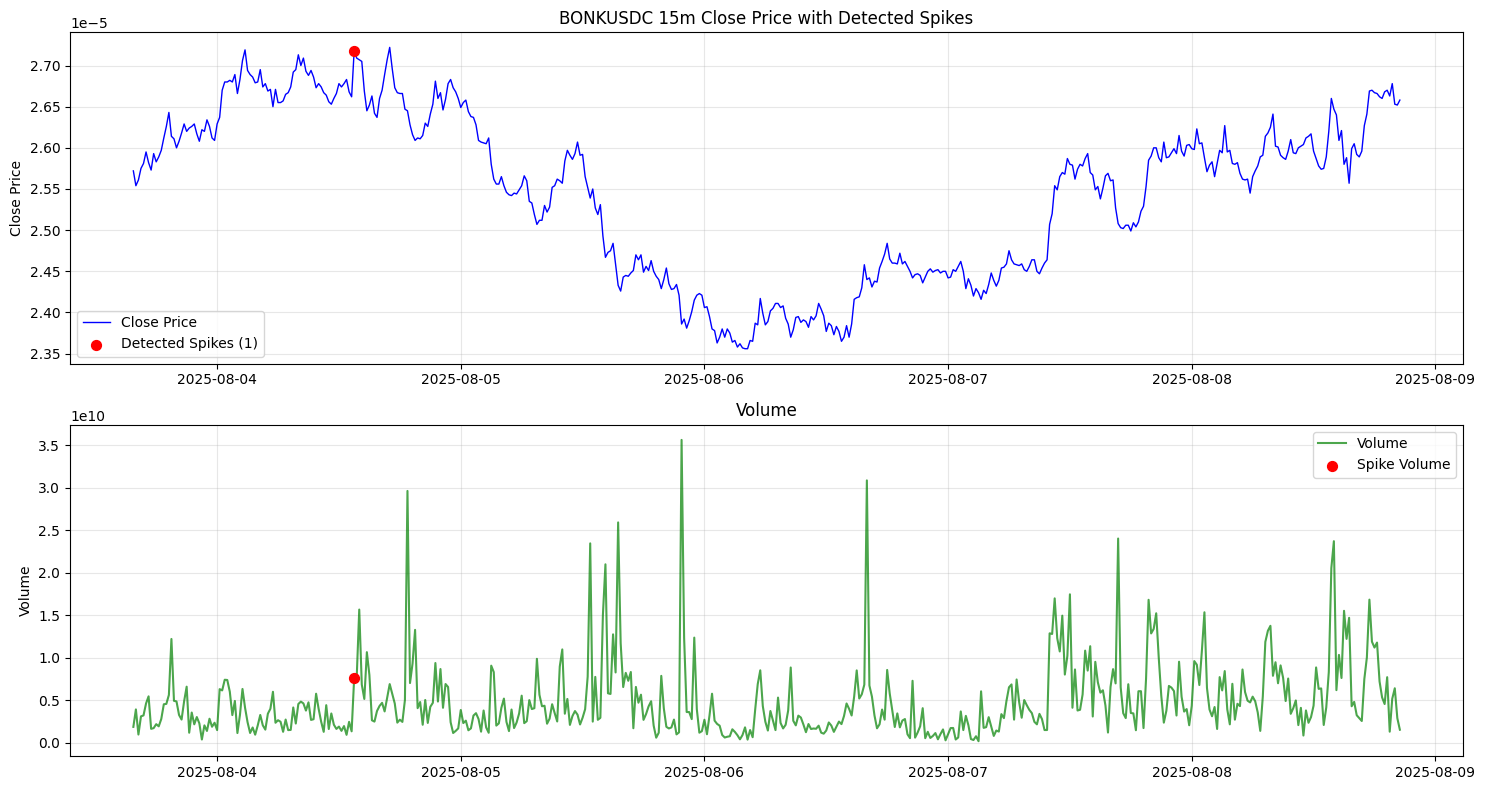

In [12]:
# === Use production SpikeHunter to predict on a random active symbol ===
import random
import matplotlib.pyplot as plt

# Pick a random symbol from the active symbols
if not active_symbols:
    print("No active symbols available.")
else:
    random_symbol = random.choice(active_symbols)
    print(f"\n🔮 Running production SpikeHunter prediction for random symbol: {random_symbol}")

    # Initialize production SpikeHunter with same settings as before
    prod_hunter = SpikeHunter(
        price_threshold=0.020,
        volume_threshold=2.0,
        momentum_threshold=0.015,
        window=12,
        rsi_oversold=30,
    )

    try:
        # Fetch fresh data for the random symbol
        df_pred, summary_pred = prod_hunter.run_analysis(random_symbol, interval="15m", limit=500, verbose=True)
        
        # Show detected spikes
        spikes_pred = df_pred[df_pred["spike_signal"] == 1]
        if not spikes_pred.empty:
            print(f"\n🔥 Detected {len(spikes_pred)} spikes for {random_symbol}:")
            print(spikes_pred[["timestamp", "close", "price_change", "volume_ratio", "spike_type", "signal_strength"]].tail(10))
        else:
            print(f"No spikes detected for {random_symbol}.")

        # --- Plot detected spikes as previously ---
        plt.figure(figsize=(15, 8))
        # Price plot
        plt.subplot(2, 1, 1)
        plt.plot(df_pred["timestamp"], df_pred["close"], label="Close Price", color="blue", linewidth=1)
        spike_indices = df_pred.index[df_pred["spike_signal"] == 1]
        if len(spike_indices) > 0:
            plt.scatter(
                df_pred.loc[spike_indices, "timestamp"],
                df_pred.loc[spike_indices, "close"],
                color="red",
                label=f"Detected Spikes ({len(spike_indices)})",
                zorder=5,
                s=50,
            )
        plt.title(f"{random_symbol} 15m Close Price with Detected Spikes")
        plt.ylabel("Close Price")
        plt.legend()
        plt.grid(True, alpha=0.3)
        # Volume plot
        plt.subplot(2, 1, 2)
        plt.plot(df_pred["timestamp"], df_pred["volume"], label="Volume", color="green", alpha=0.7)
        if len(spike_indices) > 0:
            plt.scatter(
                df_pred.loc[spike_indices, "timestamp"],
                df_pred.loc[spike_indices, "volume"],
                color="red",
                label="Spike Volume",
                zorder=5,
                s=50,
            )
        plt.title("Volume")
        plt.ylabel("Volume")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"❌ Error running prediction for {random_symbol}: {e}")

Dynamic price_threshold (95th pct): 0.0080
Dynamic volume_threshold (90th pct): 1.97
🔍 Analyzing BONKUSDC on 15m timeframe...
📊 Fetched 500 candles from 2025-08-03 18:00:00 to 2025-08-08 22:45:00
🎯 Detected 10 spikes (2.00% rate)
📈 Avg price change: 1.34%
📊 Avg volume ratio: 2.88x
⚡ Avg signal strength: 0.4
🏷️ Spike types: {'price_volume': 10}

🔥 Detected 10 spikes for BONKUSDC with dynamic thresholds.
📊 Fetched 500 candles from 2025-08-03 18:00:00 to 2025-08-08 22:45:00
🎯 Detected 10 spikes (2.00% rate)
📈 Avg price change: 1.34%
📊 Avg volume ratio: 2.88x
⚡ Avg signal strength: 0.4
🏷️ Spike types: {'price_volume': 10}

🔥 Detected 10 spikes for BONKUSDC with dynamic thresholds.


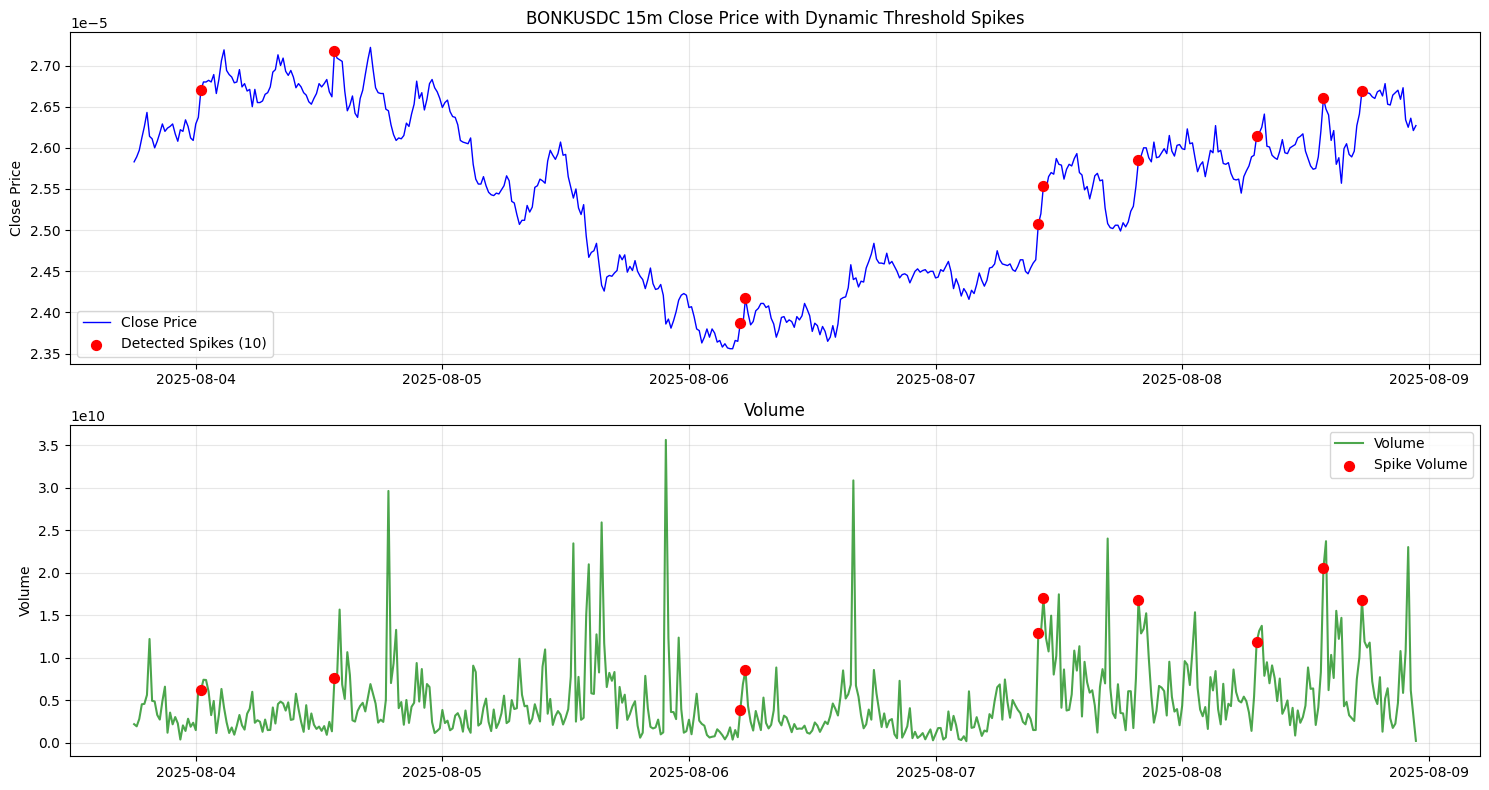

In [ ]:
# === Dynamically set thresholds based on symbol statistics ===
if not active_symbols:
    print("No active symbols available.")
else:
    # Use quantiles to set thresholds (e.g., 95th percentile for price change, 90th for volume)
    price_thresh_dynamic = df_pred["price_change"].quantile(0.95)
    vol_thresh_dynamic = df_pred["volume_ratio"].quantile(0.90)
    print(f"Dynamic price_threshold (95th pct): {price_thresh_dynamic:.4f}")
    print(f"Dynamic volume_threshold (90th pct): {vol_thresh_dynamic:.2f}")

    # Re-run detection with dynamic thresholds
    prod_hunter_dynamic = SpikeHunter(
        price_threshold=price_thresh_dynamic,
        volume_threshold=vol_thresh_dynamic,
        momentum_threshold=prod_hunter.momentum_threshold,
        window=prod_hunter.window,
        rsi_oversold=prod_hunter.rsi_oversold,
    )
    try:
        df_pred_dyn, summary_pred_dyn = prod_hunter_dynamic.run_analysis(random_symbol, interval="15m", limit=500, verbose=True)
        spikes_pred_dyn = df_pred_dyn[df_pred_dyn["spike_signal"] == 1]
        print(f"\n🔥 Detected {len(spikes_pred_dyn)} spikes for {random_symbol} with dynamic thresholds.")
        # Plot as before, but add price change subplot
        plt.figure(figsize=(15, 12))
        # Price plot
        plt.subplot(3, 1, 1)
        plt.plot(df_pred_dyn["timestamp"], df_pred_dyn["close"], label="Close Price", color="blue", linewidth=1)
        spike_indices_dyn = df_pred_dyn.index[df_pred_dyn["spike_signal"] == 1]
        if len(spike_indices_dyn) > 0:
            plt.scatter(
                df_pred_dyn.loc[spike_indices_dyn, "timestamp"],
                df_pred_dyn.loc[spike_indices_dyn, "close"],
                color="red",
                label=f"Detected Spikes ({len(spike_indices_dyn)})",
                zorder=5,
                s=50,
            )
        plt.title(f"{random_symbol} 15m Close Price with Dynamic Threshold Spikes")
        plt.ylabel("Close Price")
        plt.legend()
        plt.grid(True, alpha=0.3)
        # Volume plot
        plt.subplot(3, 1, 2)
        plt.plot(df_pred_dyn["timestamp"], df_pred_dyn["volume"], label="Volume", color="green", alpha=0.7)
        if len(spike_indices_dyn) > 0:
            plt.scatter(
                df_pred_dyn.loc[spike_indices_dyn, "timestamp"],
                df_pred_dyn.loc[spike_indices_dyn, "volume"],
                color="red",
                label="Spike Volume",
                zorder=5,
                s=50,
            )
        plt.title("Volume")
        plt.ylabel("Volume")
        plt.legend()
        plt.grid(True, alpha=0.3)
        # Price change plot
        plt.subplot(3, 1, 3)
        plt.plot(df_pred_dyn["timestamp"], df_pred_dyn["price_change"] * 100, label="Price Change %", color="purple", alpha=0.7)
        if len(spike_indices_dyn) > 0:
            plt.scatter(
                df_pred_dyn.loc[spike_indices_dyn, "timestamp"],
                df_pred_dyn.loc[spike_indices_dyn, "price_change"] * 100,
                color="red",
                label="Spike Price Change",
                zorder=5,
                s=50,
            )
        plt.axhline(y=price_thresh_dynamic * 100, color="orange", linestyle="--", label=f"Threshold ({price_thresh_dynamic*100:.2f}%)")
        plt.title("Price Change % (Red = Detected Spikes)")
        plt.xlabel("Timestamp")
        plt.ylabel("Price Change %")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"❌ Error running dynamic threshold prediction for {random_symbol}: {e}")

In [14]:
# === Analyze why detection rate is low for the random symbol ===
if not active_symbols:
    print("No active symbols available.")
else:
    print(f"\n--- Detection Rate Analysis for {random_symbol} ---")
    print(f"Total candles: {len(df_pred)}")
    print(f"Spikes detected: {len(spikes_pred)}")
    if len(df_pred) > 0:
        print(f"Detection rate: {len(spikes_pred)/len(df_pred):.4f}")
    
    # Show price change and volume ratio statistics
    print("\nPrice change statistics:")
    print(df_pred["price_change"].describe())
    print("\nVolume ratio statistics:")
    print(df_pred["volume_ratio"].describe())
    
    # Show how many candles exceed the thresholds
    price_thresh = prod_hunter.price_threshold
    vol_thresh = prod_hunter.volume_threshold
    price_spikes = df_pred[df_pred["price_change"] > price_thresh]
    vol_spikes = df_pred[df_pred["volume_ratio"] > vol_thresh]
    both_spikes = df_pred[(df_pred["price_change"] > price_thresh) & (df_pred["volume_ratio"] > vol_thresh)]
    print(f"\nCandles with price_change > {price_thresh:.3f}: {len(price_spikes)}")
    print(f"Candles with volume_ratio > {vol_thresh:.2f}: {len(vol_spikes)}")
    print(f"Candles with BOTH > thresholds: {len(both_spikes)}")
    
    # Show some of the largest price changes and volume ratios
    print("\nTop 5 price changes:")
    print(df_pred.nlargest(5, "price_change")[["timestamp", "close", "price_change", "volume_ratio"]])
    print("\nTop 5 volume ratios:")
    print(df_pred.nlargest(5, "volume_ratio")[["timestamp", "close", "price_change", "volume_ratio"]])
    
    # Check if the symbol is generally low volatility or low volume
    print("\nMean close price:", df_pred["close"].mean())
    print("Mean volume:", df_pred["volume"].mean())
    print("Std price_change:", df_pred["price_change"].std())
    print("Std volume_ratio:", df_pred["volume_ratio"].std())
    
    print("\nIf very few candles exceed the thresholds, consider lowering price_threshold or volume_threshold, or check if the symbol is inactive/illiquid.")


--- Detection Rate Analysis for BONKUSDC ---
Total candles: 500
Spikes detected: 1
Detection rate: 0.0020

Price change statistics:
count    499.000000
mean       0.000080
std        0.005223
min       -0.015643
25%       -0.002984
50%        0.000000
75%        0.003083
max        0.021037
Name: price_change, dtype: float64

Volume ratio statistics:
count    500.000000
mean       1.031600
std        0.758307
min        0.120396
25%        0.538504
50%        0.819043
75%        1.275888
max        6.915241
Name: volume_ratio, dtype: float64

Candles with price_change > 0.020: 1
Candles with volume_ratio > 2.00: 48
Candles with BOTH > thresholds: 1

Top 5 price changes:
              timestamp     close  price_change  volume_ratio
87  2025-08-04 13:30:00  0.000027      0.021037      2.948439
361 2025-08-07 10:00:00  0.000025      0.017451      3.315917
480 2025-08-08 15:45:00  0.000026      0.016425      0.398220
472 2025-08-08 13:45:00  0.000027      0.015267      3.460426
363 2025-0